In [1]:
import gymnasium as gym
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import gym
import numpy as np

np.bool8 = np.bool

# We create the environment
class ExoSim(gym.Env):
    def __init__(self):
        super().__init__()

        self.target = [1.5, -1.0]
        self.bones = [1.0, 1.0, 0.5]

        # Observation space: 3 joints angular position and target (x,y)
        self.observation_space = gym.spaces.Box(
            low=-3.0, high=3.0, shape=(5,), dtype=np.float32
        )

        # Action space: 3 joints position change
        self.action_space = gym.spaces.Box(
            low=-np.pi/16, high=np.pi/16, shape=(3,), dtype=np.float32
        )

        self.state = None
        self.max_steps = 250
        self.steps = 0

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset()
        # Start with a random 3-D vector
        q0 = (np.random.rand()-0.5)*np.pi/16
        q1 = (np.random.rand()-0.5)*np.pi/16
        q2 = (np.random.rand()-0.5)*np.pi/16
        
        self.state = np.array([q0, q1, q2, self.target[0], self.target[1]], dtype=np.float32)
        self.steps = 0
        return self.state, {}

    def step(self, action):
        self.steps += 1   # increment step count
        # We transform the action from [-1, 1] to the appropiate range
        action = action.astype(np.float32) * (np.pi/16)
        
        # Exoskeleton forward dynamics:
        q0 = np.clip(self.state[0]+action[0], -np.pi, np.pi)
        q1 = np.clip(self.state[1]+action[1], -np.pi, np.pi)
        q2 = np.clip(self.state[2]+action[2], -np.pi, np.pi)

        knee = [self.bones[0]*np.sin(q0), -self.bones[0]*np.cos(q0)]
        ankle = [knee[0]+self.bones[1]*np.sin(q0-q1), knee[1]-self.bones[1]*np.cos(q0-q1)]
        toes = [ankle[0]+self.bones[2]*np.sin(q0-q1+np.pi/2+q2), ankle[1]+self.bones[2]*np.cos(q0-q1+np.pi/2+q2)]

        #print('Knee: ',knee)
        #print('Ankle: ',ankle)
        #print('Toes: ',toes)

        # next_state
        self.state = np.array([float(q0), float(q1), float(q2), self.target[0], self.target[1]], dtype=np.float32)

        # Reward: try to reach the target
        distance = [toes[0]-self.target[0], toes[1]-self.target[1]]
        reward = -abs(np.linalg.norm(distance))
        if abs(np.linalg.norm(distance)) < 0.1:
            reward = reward+1

        # Terminate when close enough to origin
        terminated = abs(np.linalg.norm(distance)) < 0.1
        truncated = self.steps >= self.max_steps

        return self.state, reward, terminated, truncated, {}

    def render(self):
        print("State:", self.state)


# Simple neural networks for Actor and Critic
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
        )
        self.mean = nn.Linear(64, action_dim)

        # log_std as a learnable parameter (good enough for PPO)
        self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, s):
        x = self.net(s)
        mean = self.mean(x)
        std = torch.exp(self.log_std)
        return torch.distributions.Normal(mean, std)

class Critic(nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, s):
        return self.net(s).squeeze(-1)

# Generalized Advantage Estimation
def compute_advantage(rewards, values, dones, last_value, gamma=0.99, lam=0.95):
    advantage = 0
    advantages = []
    returns = []
    values = values + [last_value]

    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * values[t+1] * (1 - dones[t]) - values[t]
        advantage = delta + gamma * lam * (1 - dones[t]) * advantage
        advantages.insert(0, advantage)

    for t in range(len(advantages)):
        returns.append(advantages[t]+values[t])
    
    return (
        torch.tensor(advantages, dtype=torch.float32),
        torch.tensor(returns, dtype=torch.float32)
    )

# PPO Update Step
def ppo_update(actor, critic, opt_actor, opt_critic,
               batch, clip_eps=0.2,
               epochs=10, minibatch_size=64):

    states, actions, logps_old, returns, advantages = batch
    n = len(states)
    idexes = np.arange(n) # We create an array from 0 to n-1

    # First we normalize the advantages to mean 0, std 1
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    # We do several learning epochs over the same data
    for _ in range(epochs):
        np.random.shuffle(idexes) #We randomise the order
        # We separe the indexes in minibatches
        for start in range(0, n, minibatch_size):
            minibatch = idexes[start:start+minibatch_size]
            # We extract the batch information
            mb_s = states[minibatch]
            mb_a = actions[minibatch]
            mb_old_lp = logps_old[minibatch]
            mb_returns = returns[minibatch]
            mb_adv = advantages[minibatch]

            # We compute the new log probabilities for the ratio
            dist = actor(mb_s)
            logp = dist.log_prob(mb_a) - torch.log(1 - torch.tanh(mb_a).pow(2) + 1e-7)
            lp = logp.sum(-1)

            # We calculate the ratio
            ratio = (lp - mb_old_lp).exp()

            # We calculate clipped surrogate objective
            unclipped = ratio * mb_adv
            clipped = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * mb_adv
            actor_loss = -torch.min(unclipped, clipped).mean()

            # We calculate the critic loss by predicting the values
            value_pred = critic(mb_s)
            critic_loss = F.mse_loss(value_pred.float(), mb_returns.float())

            # Update actor
            opt_actor.zero_grad()
            actor_loss.backward()
            opt_actor.step()

            # Update critic
            opt_critic.zero_grad()
            critic_loss.backward()
            opt_critic.step()


# PPO Training Loop
def train_ppo():
    env = ExoSim()
    state_dim = env.observation_space.shape[0]
    n_actions = 3

    actor = Actor(state_dim, n_actions)
    critic = Critic(state_dim)

    opt_actor = torch.optim.Adam(actor.parameters(), lr=3e-4)
    opt_critic = torch.optim.Adam(critic.parameters(), lr=1e-3)

    steps_per_update = 2048
    obs, _ = env.reset()
    ep_reward = 0
    rewards_array = []
    
    for update in range(500):
        # We prepare the batch results
        states, actions, logps, rewards, dones, values = [], [], [], [], [], []

        # We interact with the environment
        for step in range(steps_per_update):
            state = torch.tensor(obs, dtype=torch.float32)
            dist = actor(state)

            # We get the action and turn it into what the env expects
            raw_action = dist.sample()
            action = torch.tanh(raw_action) #From -1 to 1

            logp = dist.log_prob(raw_action) - torch.log(1 - action.pow(2) + 1e-7)
            lp = logp.sum(-1)

            # We get the value of the state and perform a step
            value = critic(state).item()

            next_obs, reward, terminated, truncated, _ = env.step(action.numpy())
            done = terminated or truncated

            # We store in the batch all the results from this step
            states.append(obs)
            actions.append(raw_action.numpy())
            logps.append(lp.item())
            values.append(value)
            rewards.append(reward)
            dones.append(done)
            
            ep_reward += reward
            obs = next_obs
            # if done, we perform a reset
            if done:
                print("Episode reward:", ep_reward)
                rewards_array.append(float(ep_reward))
                ep_reward = 0
                obs, _ = env.reset()
                
        # We prepare the batch by turning them into tensors
        states = torch.tensor(states, dtype=torch.float32)
        actions = torch.tensor(actions)
        logps_old = torch.tensor(logps, dtype=torch.float32)

        # We generate the last state value (predicting it)
        last_value = critic(torch.tensor(obs, dtype=torch.float32)).item()

        advantage, returns = compute_advantage(rewards, values, dones, last_value)

        # We update the ppo
        batch = (states, actions, logps_old, returns, advantage)
        ppo_update(actor, critic, opt_actor, opt_critic, batch)

        print(f"~~~~ PPO update: {update} finished ~~~~")
        if update%10 == 0:
            print(rewards_array)



if __name__ == "__main__":
    train_ppo()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Episode reward: -523.922
Episode reward: -591.33636
Episode reward: -577.4125
Episode reward: -558.6104
Episode reward: -500.0908
Episode reward: -569.5544
Episode reward: -594.14764
Episode reward: -537.39935


C:\Users\jgagu\AppData\Local\Temp\ipykernel_29968\3015373134.py:244: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  states = torch.tensor(states, dtype=torch.float32)


~~~~ PPO update: 0 finished ~~~~
[-523.9219970703125, -591.3363647460938, -577.4124755859375, -558.6104125976562, -500.0907897949219, -569.5543823242188, -594.1476440429688, -537.3993530273438]
Episode reward: -464.81387
Episode reward: -413.47192
Episode reward: -492.60443
Episode reward: -507.1529
Episode reward: -493.34833
Episode reward: -484.07568
Episode reward: -410.39383
Episode reward: -527.0427
~~~~ PPO update: 1 finished ~~~~
Episode reward: -437.25323
Episode reward: -675.4355
Episode reward: -395.73895
Episode reward: -453.11508
Episode reward: -528.54663
Episode reward: -472.71667
Episode reward: -364.64218
Episode reward: -443.4071
~~~~ PPO update: 2 finished ~~~~
Episode reward: -533.3156
Episode reward: -491.61465
Episode reward: -641.5876
Episode reward: -612.2412
Episode reward: -491.54056
Episode reward: -388.95184
Episode reward: -27.972343
Episode reward: -518.8689
Episode reward: -470.03342
~~~~ PPO update: 3 finished ~~~~
Episode reward: -385.48672
Episode rewar

KeyboardInterrupt: 

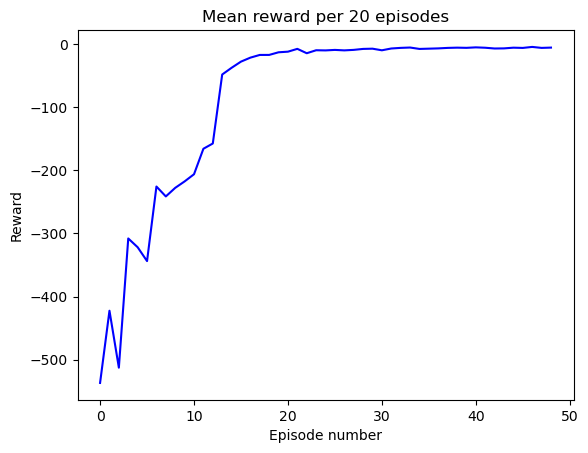

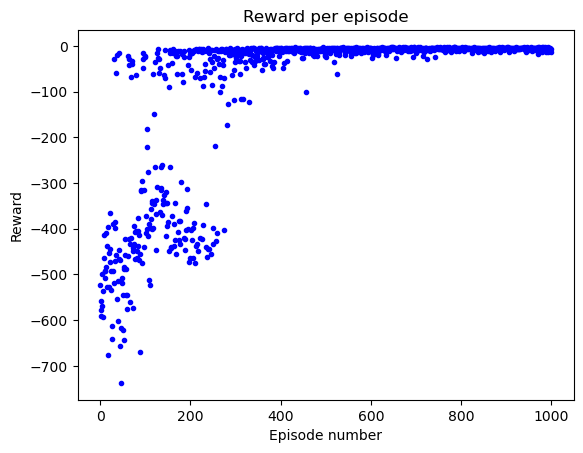

Spearmans rank correlation:  0.9582653061224488


In [4]:
import matplotlib.pyplot as plt
import numpy as np
x2 = [-523.9219970703125, -591.3363647460938, -577.4124755859375, -558.6104125976562, -500.0907897949219, -569.5543823242188, -594.1476440429688, -537.3993530273438, -464.8138732910156, -413.471923828125, -492.60443115234375, -507.15289306640625, -493.34832763671875, -484.07568359375, -410.3938293457031, -527.042724609375, -437.25323486328125, -675.4354858398438, -395.73895263671875, -453.1150817871094, -528.546630859375, -472.7166748046875, -364.6421813964844, -443.4071044921875, -533.3156127929688, -491.6146545410156, -641.5875854492188, -612.2412109375, -491.5405578613281, -388.95184326171875, -27.97234344482422, -518.868896484375, -470.0334167480469, -385.4867248535156, -398.73028564453125, -457.6361083984375, -60.182281494140625, -20.307228088378906, -554.0081787109375, -601.9137573242188, -514.1471557617188, -447.1671142578125, -467.05194091796875, -15.036712646484375, -655.6292724609375, -469.40643310546875, -737.4866333007812, -617.1287231445312, -508.680908203125, -519.4527587890625, -621.7431030273438, -544.3543701171875, -483.4557189941406, -643.9232177734375, -487.77490234375, -457.54949951171875, -423.027099609375, -544.2931518554688, -487.9834899902344, -545.2257690429688, -576.1963500976562, -458.8732604980469, -21.72146987915039, -28.183513641357422, -423.1718444824219, -41.63526916503906, -432.7046813964844, -559.5362548828125, -421.13330078125, -67.4993896484375, -32.71390151977539, -39.578094482421875, -441.33978271484375, -449.2899169921875, -573.2254028320312, -393.2685546875, -432.9320373535156, -466.88018798828125, -407.27252197265625, -404.98822021484375, -64.45198059082031, -463.7880554199219, -449.3386535644531, -404.47137451171875, -437.9703674316406, -377.40997314453125, -469.4029235839844, -412.83721923828125, -669.69970703125, -456.1411437988281, -318.4505615234375, -315.2635803222656, -294.83709716796875, -475.9330749511719, -15.935328483581543, -27.88822364807129, -47.285396575927734, -315.1736145019531, -439.2400207519531, -21.969959259033203, -25.150991439819336, -372.62408447265625, -409.19073486328125, -222.03009033203125, -401.1702880859375, -182.7163543701172, -276.197509765625, -416.630859375, -389.8711853027344, -512.6525268554688, -523.9275512695312, -397.61383056640625, -355.9165344238281, -378.84979248046875, -400.90155029296875, -338.4537353515625, -344.6379089355469, -60.39393615722656, -397.8031005859375, -149.9494171142578, -345.5873718261719, -35.54673767089844, -264.117919921875, -367.9669189453125, -446.7148132324219, -336.5929260253906, -309.23193359375, -15.748651504516602, -7.076295375823975, -26.935504913330078, -59.49952697753906, -28.399507522583008, -363.08917236328125, -48.67924118041992, -315.90948486328125, -264.3806457519531, -311.4857482910156, -260.62615966796875, -370.3600158691406, -346.1562805175781, -337.04498291015625, -325.79571533203125, -63.983802795410156, -69.74211120605469, -9.543466567993164, -415.27374267578125, -319.66033935546875, -342.6869201660156, -342.69091796875, -393.8695068359375, -42.576507568359375, -385.2970275878906, -449.59423828125, -89.7772216796875, -264.6957092285156, -8.43308162689209, -15.042506217956543, -438.93017578125, -442.7790832519531, -371.40325927734375, -37.51235580444336, -14.707674980163574, -7.497406959533691, -437.232666015625, -390.4643249511719, -424.6521911621094, -10.91887378692627, -343.138671875, -21.810741424560547, -456.4009704589844, -21.473480224609375, -61.70561981201172, -11.458551406860352, -406.9260559082031, -424.21624755859375, -383.2177429199219, -384.17156982421875, -11.705400466918945, -434.449462890625, -14.338800430297852, -297.0771179199219, -61.2088508605957, -18.683761596679688, -78.99771118164062, -12.187220573425293, -24.746091842651367, -419.8622741699219, -10.243257522583008, -423.6022033691406, -445.8507995605469, -402.6352844238281, -360.31866455078125, -353.7276611328125, -313.2403869628906, -40.734596252441406, -400.733642578125, -23.789627075195312, -473.68414306640625, -9.129156112670898, -16.71149444580078, -463.2380065917969, -53.658634185791016, -403.37530517578125, -15.984837532043457, -424.0267028808594, -463.5638122558594, -398.3783874511719, -10.290635108947754, -8.535072326660156, -386.7985534667969, -475.0835266113281, -67.32540130615234, -7.002712726593018, -436.9446105957031, -59.050071716308594, -433.513916015625, -449.5794982910156, -10.888940811157227, -8.062499046325684, -7.267937183380127, -6.895971775054932, -69.26239013671875, -419.65966796875, -10.060151100158691, -7.400907516479492, -422.8879699707031, -13.599294662475586, -390.84552001953125, -88.74962615966797, -5.8746795654296875, -10.561158180236816, -68.40376281738281, -38.846858978271484, -53.885318756103516, -346.2950439453125, -440.79010009765625, -11.70502758026123, -462.9748840332031, -9.347683906555176, -444.73101806640625, -3.4647130966186523, -14.894509315490723, -445.0619812011719, -57.07619094848633, -28.272464752197266, -9.344442367553711, -455.5799255371094, -36.1024169921875, -8.522422790527344, -84.70153045654297, -398.7831115722656, -432.64898681640625, -49.33376693725586, -22.98199462890625, -8.398005485534668, -219.3868408203125, -427.5899963378906, -7.193813323974609, -409.20343017578125, -9.309489250183105, -28.630342483520508, -25.786855697631836, -10.638751983642578, -11.365418434143066, -38.5765266418457, -101.50885772705078, -68.56578063964844, -12.136763572692871, -5.760700225830078, -9.386837005615234, -87.06549072265625, -6.3232951164245605, -30.02980613708496, -41.206912994384766, -402.49981689453125, -69.95729064941406, -8.797309875488281, -13.756028175354004, -6.536656379699707, -7.077485084533691, -11.248075485229492, -172.18307495117188, -9.050271987915039, -11.621362686157227, -127.33966827392578, -12.208470344543457, -20.610004425048828, -20.141834259033203, -5.46578311920166, -12.177433013916016, -6.272188663482666, -18.722576141357422, -63.00815200805664, -18.605573654174805, -14.900985717773438, -9.82132625579834, -118.43534088134766, -53.67824172973633, -5.612738132476807, -35.1678466796875, -20.17977523803711, -25.70429229736328, -16.34096336364746, -14.180397033691406, -4.58683967590332, -5.943626880645752, -8.211580276489258, -18.906139373779297, -32.76588821411133, -61.200279235839844, -16.854490280151367, -32.981712341308594, -115.0981216430664, -21.67407989501953, -6.986710548400879, -15.300956726074219, -14.809444427490234, -115.11248779296875, -8.269408226013184, -12.91163444519043, -11.989311218261719, -14.654167175292969, -34.15830993652344, -48.9572639465332, -7.66758918762207, -14.80825138092041, -5.01377010345459, -7.937990188598633, -5.949802875518799, -17.842445373535156, -15.250004768371582, -122.93829345703125, -10.741199493408203, -30.31655502319336, -5.344948768615723, -6.014263153076172, -19.176986694335938, -34.15874099731445, -5.111169815063477, -4.84722375869751, -22.7784423828125, -3.5507662296295166, -41.00330352783203, -7.1091203689575195, -32.234867095947266, -10.17802906036377, -31.752748489379883, -31.552936553955078, -21.55937957763672, -9.622215270996094, -12.387945175170898, -7.9808735847473145, -30.60960578918457, -5.492587089538574, -7.783630847930908, -7.0911865234375, -4.005410194396973, -4.230010509490967, -52.330177307128906, -12.803728103637695, -14.939864158630371, -26.67357063293457, -28.20685577392578, -12.792842864990234, -39.07392120361328, -38.4639778137207, -10.781282424926758, -4.938008785247803, -8.084084510803223, -13.149079322814941, -23.70857048034668, -11.402478218078613, -24.23244857788086, -7.89982795715332, -8.060786247253418, -10.201007843017578, -33.39759826660156, -5.673772811889648, -14.965789794921875, -6.900407791137695, -18.910682678222656, -43.157989501953125, -9.144438743591309, -48.294734954833984, -7.719409942626953, -7.624378681182861, -35.00663375854492, -8.173681259155273, -4.196529388427734, -10.012473106384277, -4.224207401275635, -4.506735801696777, -4.4368696212768555, -9.026501655578613, -10.018045425415039, -6.2106475830078125, -5.369364261627197, -21.489824295043945, -11.66215991973877, -8.367293357849121, -5.5962371826171875, -3.8746867179870605, -5.6852335929870605, -12.491290092468262, -7.540083408355713, -47.6821174621582, -6.311392784118652, -37.0504035949707, -10.826057434082031, -7.99845027923584, -3.9537556171417236, -6.635247230529785, -4.9196014404296875, -11.09721851348877, -3.825685977935791, -32.16022491455078, -11.27772045135498, -7.825549602508545, -10.520689010620117, -4.600132465362549, -8.423990249633789, -7.149723529815674, -5.213711738586426, -6.695639610290527, -5.797181606292725, -10.842960357666016, -4.807905197143555, -12.174172401428223, -9.172628402709961, -15.124895095825195, -8.902435302734375, -9.122725486755371, -3.3237340450286865, -6.159958839416504, -4.233208656311035, -7.465978145599365, -7.490017414093018, -8.339275360107422, -4.927133083343506, -9.007696151733398, -9.756317138671875, -12.104222297668457, -4.911233425140381, -8.651327133178711, -4.918435096740723, -10.058966636657715, -13.397164344787598, -25.41989517211914, -6.164207458496094, -25.741600036621094, -13.962740898132324, -4.436956882476807, -10.791797637939453, -7.833927631378174, -4.721831798553467, -14.88092041015625, -5.363643169403076, -101.31140899658203, -4.955449104309082, -10.35633659362793, -4.019455909729004, -12.64255428314209, -14.654211044311523, -6.810591220855713, -5.211281776428223, -3.6122617721557617, -3.990039110183716, -10.177384376525879, -6.127964496612549, -6.337302207946777, -9.081513404846191, -4.839934825897217, -20.35129737854004, -22.490419387817383, -13.553352355957031, -7.560991287231445, -17.48680305480957, -9.779624938964844, -6.482730388641357, -10.127352714538574, -8.229795455932617, -22.14653778076172, -9.446529388427734, -6.270602226257324, -8.726231575012207, -10.572729110717773, -6.892424583435059, -5.7043046951293945, -11.678731918334961, -6.386014938354492, -6.727437496185303, -4.064637660980225, -11.205024719238281, -6.667838096618652, -3.0438456535339355, -7.493433475494385, -5.749993324279785, -7.019890785217285, -18.74461555480957, -21.6289119720459, -24.40979766845703, -7.145166873931885, -12.58435344696045, -4.076043605804443, -10.15310287475586, -13.214808464050293, -7.42498254776001, -5.262868881225586, -9.89648151397705, -7.171360492706299, -16.522571563720703, -8.55371379852295, -3.4550859928131104, -6.515674591064453, -4.485526084899902, -7.918525695800781, -5.544803142547607, -9.607083320617676, -4.947628974914551, -35.277191162109375, -9.098100662231445, -4.430607795715332, -18.626754760742188, -12.097655296325684, -4.239374160766602, -62.2969856262207, -3.8311142921447754, -5.910459041595459, -9.521882057189941, -19.870275497436523, -12.638656616210938, -4.403513431549072, -5.31116247177124, -4.656623363494873, -5.326404094696045, -3.8498737812042236, -4.538471698760986, -4.102789402008057, -6.530453205108643, -2.7885727882385254, -8.678342819213867, -8.092533111572266, -18.94438934326172, -15.361991882324219, -3.8921854496002197, -10.147793769836426, -8.653050422668457, -5.892378330230713, -5.131562232971191, -4.896138668060303, -9.836567878723145, -8.797751426696777, -5.235764026641846, -9.991196632385254, -7.52182674407959, -3.557319164276123, -21.809301376342773, -15.398761749267578, -13.043225288391113, -6.151036739349365, -5.481383800506592, -6.702061653137207, -5.340559005737305, -4.8576483726501465, -8.228278160095215, -14.852458000183105, -14.787906646728516, -3.139166831970215, -7.459634304046631, -7.145263671875, -4.221624374389648, -7.463521957397461, -4.783904552459717, -4.8688435554504395, -10.259146690368652, -9.41826343536377, -4.787978172302246, -10.1123046875, -6.9904398918151855, -14.87130355834961, -7.138120651245117, -5.111578464508057, -4.142548084259033, -7.919075012207031, -7.681522846221924, -13.213004112243652, -9.152305603027344, -7.99479341506958, -4.079985618591309, -11.020795822143555, -5.306602954864502, -8.443464279174805, -3.383960723876953, -10.549398422241211, -12.480179786682129, -5.578716278076172, -7.659106254577637, -4.288741111755371, -4.881093978881836, -6.3955535888671875, -10.769305229187012, -3.530031204223633, -13.431593894958496, -27.23394012451172, -10.568171501159668, -18.760847091674805, -6.604038238525391, -4.748903751373291, -8.876677513122559, -6.135623455047607, -7.972935199737549, -8.310589790344238, -10.392868995666504, -3.8348827362060547, -4.937783241271973, -20.88412094116211, -17.94151496887207, -4.946626663208008, -6.7215704917907715, -10.809473991394043, -4.388825416564941, -4.6307053565979, -6.0354509353637695, -6.588685512542725, -2.604302406311035, -5.1390228271484375, -4.190167427062988, -9.939797401428223, -9.628043174743652, -4.612837314605713, -4.964411735534668, -4.434229850769043, -10.556339263916016, -19.27684211730957, -11.025557518005371, -7.5693159103393555, -3.89139986038208, -4.149670124053955, -7.546234130859375, -6.605596542358398, -10.700780868530273, -3.598578929901123, -4.599010467529297, -6.234854221343994, -4.080469131469727, -2.8380959033966064, -6.136192798614502, -3.236649513244629, -4.540318965911865, -6.927884578704834, -2.7105724811553955, -4.787846565246582, -4.338909149169922, -6.871604919433594, -4.260235786437988, -4.454500675201416, -25.862491607666016, -6.216476917266846, -11.9393892288208, -7.232721328735352, -3.6796517372131348, -7.07468843460083, -3.4070184230804443, -8.471405982971191, -6.75141716003418, -3.540870428085327, -12.52476978302002, -3.753946542739868, -5.358057975769043, -3.7383761405944824, -5.513782024383545, -3.2333221435546875, -4.251323223114014, -5.737138271331787, -7.9923553466796875, -5.797114849090576, -2.760010242462158, -5.241143226623535, -5.292710304260254, -4.633512496948242, -8.503862380981445, -5.406745910644531, -4.908927917480469, -11.90462589263916, -4.4098405838012695, -8.37040901184082, -11.578109741210938, -3.8810248374938965, -3.2357120513916016, -8.92247200012207, -6.357463836669922, -8.172039985656738, -8.500383377075195, -6.011035919189453, -24.199954986572266, -3.392645835876465, -2.660463571548462, -5.788760662078857, -9.34571647644043, -14.386481285095215, -6.301436901092529, -6.162193298339844, -8.248479843139648, -10.386885643005371, -3.390625476837158, -5.697256088256836, -3.79479718208313, -4.394532203674316, -3.365002393722534, -7.276859283447266, -9.675825119018555, -5.896204948425293, -6.000314712524414, -8.672492027282715, -9.306915283203125, -4.948154449462891, -22.475603103637695, -9.035429000854492, -13.226765632629395, -3.5633139610290527, -3.8715343475341797, -3.487072229385376, -3.754380226135254, -5.17259407043457, -27.646957397460938, -9.796778678894043, -5.972002029418945, -8.636491775512695, -7.3805012702941895, -3.774016857147217, -6.810654640197754, -5.705337047576904, -10.363724708557129, -5.173642635345459, -4.474502086639404, -4.173239231109619, -4.150625228881836, -4.864157676696777, -7.23568058013916, -3.9660518169403076, -8.14151382446289, -5.669657230377197, -24.744441986083984, -4.768879413604736, -5.327544212341309, -3.61553955078125, -3.205644130706787, -4.63004207611084, -5.025287628173828, -7.192900657653809, -4.751770973205566, -7.468097686767578, -4.434002876281738, -3.3202850818634033, -5.81331729888916, -5.809970378875732, -3.677438259124756, -4.216662883758545, -7.0653557777404785, -5.782085418701172, -8.808685302734375, -5.142707824707031, -7.117230415344238, -3.043233871459961, -13.556669235229492, -4.262351036071777, -4.277458667755127, -3.8302013874053955, -3.1298234462738037, -8.48653793334961, -8.911035537719727, -5.332871913909912, -6.419715404510498, -3.8260862827301025, -2.926577091217041, -6.027041435241699, -3.5098018646240234, -12.297019958496094, -6.782635688781738, -4.332232475280762, -4.270872116088867, -5.564853668212891, -7.969747543334961, -4.958681106567383, -3.3733935356140137, -3.3271896839141846, -4.023514747619629, -3.117539405822754, -7.223316669464111, -11.164466857910156, -5.180627822875977, -7.379382610321045, -6.4546027183532715, -9.6019287109375, -5.387751579284668, -4.302637100219727, -10.948586463928223, -5.647536277770996, -3.6203014850616455, -6.315060138702393, -7.726540565490723, -7.340357303619385, -3.2037320137023926, -7.751962661743164, -3.8088059425354004, -6.964797019958496, -10.672825813293457, -3.718226909637451, -3.187434434890747, -5.367297172546387, -3.8419060707092285, -3.8384571075439453, -5.196704387664795, -5.186053276062012, -6.996315956115723, -6.361286163330078, -5.481629848480225, -3.517758846282959, -4.288324356079102, -5.798933029174805, -5.86411190032959, -6.3165106773376465, -3.741450548171997, -14.398599624633789, -5.9298810958862305, -3.456416130065918, -3.7360129356384277, -5.793574810028076, -3.1590824127197266, -4.422857284545898, -5.294790744781494, -4.832825660705566, -6.1415276527404785, -7.954012393951416, -4.055333137512207, -5.284115314483643, -5.764937877655029, -5.141209125518799, -13.309751510620117, -5.565876007080078, -5.783206462860107, -4.119894981384277, -11.501199722290039, -8.848875045776367, -11.384427070617676, -8.606792449951172, -4.776942729949951, -5.984005928039551, -5.332066535949707, -9.382509231567383, -14.584968566894531, -3.774592161178589, -4.036229610443115, -6.0930094718933105, -4.424595832824707, -6.065045356750488, -7.9156999588012695, -3.7852625846862793, -7.881545066833496, -11.399153709411621, -4.245179653167725, -3.011239767074585, -8.989899635314941, -8.868453025817871, -8.799324989318848, -3.515275478363037, -13.605071067810059, -10.449051856994629, -8.068122863769531, -5.418708801269531, -6.693811416625977, -5.513751983642578, -7.788628578186035, -3.853320598602295, -10.897201538085938, -6.395894527435303, -9.140237808227539, -3.519587993621826, -6.495858669281006, -4.8329925537109375, -4.550982475280762, -3.7938599586486816, -6.2560930252075195, -3.3915858268737793, -8.246196746826172, -5.760146141052246, -6.5153303146362305, -12.80233097076416, -4.946532726287842, -9.13819408416748, -6.0819807052612305, -2.9971609115600586, -5.586256504058838, -4.4047722816467285, -3.9621195793151855, -8.352015495300293, -5.45996618270874, -6.39965295791626, -4.965651988983154, -4.0557756423950195, -5.204645156860352, -2.1500658988952637, -4.751866340637207, -7.168684959411621, -2.4713082313537598, -12.232551574707031, -7.410404205322266, -10.597650527954102, -5.561469078063965, -4.109734058380127, -7.7419538497924805, -5.001527309417725, -6.400895595550537, -5.047206878662109, -7.053431987762451, -4.207319736480713, -7.647541522979736, -10.624238014221191, -3.592350482940674, -3.5289273262023926, -8.66206169128418, -3.060643196105957, -5.015519142150879, -4.123475074768066, -3.4882051944732666, -7.215008735656738, -6.242829322814941, -4.670085430145264, -7.687777519226074, -4.2340850830078125, -3.6819498538970947, -7.668046474456787, -4.5710577964782715, -5.283210277557373, -3.690864086151123, -4.432529926300049, -3.486534357070923, -4.009031295776367, -4.590718746185303, -2.645205497741699, -4.46608304977417, -5.783900737762451, -7.884172439575195, -12.30936050415039, -4.141380310058594, -2.9619357585906982, -4.006422996520996, -4.285017490386963, -4.509652137756348, -4.765831470489502, -6.298313140869141, -9.952549934387207, -6.379208087921143, -4.2893524169921875, -6.645248889923096, -2.805088520050049, -4.654094219207764, -7.745967388153076, -11.534725189208984, -4.850164890289307, -9.30639362335205, -5.010619640350342, -4.76145076751709, -3.5007240772247314, -9.638595581054688, -4.125736236572266, -4.5180583000183105, -3.9371047019958496, -4.945766925811768, -5.278499126434326, -17.458951950073242, -2.928948163986206, -7.999418258666992, -2.8127613067626953, -5.856855392456055, -3.6680259704589844, -4.808022499084473, -4.777442455291748, -3.0494954586029053, -12.465104103088379, -4.092683792114258, -6.171424388885498, -2.444056987762451, -4.3166704177856445, -6.01284646987915, -3.290900707244873, -7.2466721534729, -4.732455730438232, -12.991856575012207, -4.539488792419434, -4.353087902069092, -5.821957588195801, -13.646671295166016, -3.3526413440704346, -5.784991264343262, -4.885098457336426, -8.229233741760254, -3.9486231803894043, -12.404403686523438, -6.098715782165527, -4.201720714569092, -2.9003102779388428, -6.537642478942871, -5.6998610496521, -4.925232887268066, -6.476079940795898, -4.3381171226501465, -4.757135391235352, -7.847259521484375, -9.435689926147461, -2.6282336711883545, -4.527020454406738, -3.329921245574951, -6.6921706199646, -5.664155006408691, -9.000843048095703, -7.7808074951171875, -8.742006301879883, -9.026162147521973, -9.814841270446777, -5.157589912414551, -4.968886375427246, -4.110764503479004, -5.437694072723389, -3.6424999237060547, -4.158055782318115, -5.665958404541016, -3.7384681701660156, -4.361184120178223, -3.343715190887451, -5.2542619705200195, -6.221268177032471, -6.892250061035156, -5.18690299987793, -9.527389526367188, -6.318411827087402, -3.4785940647125244, -2.8273396492004395, -4.832324028015137, -4.733536243438721, -5.156331539154053, -4.222296237945557, -4.958036422729492, -3.9412951469421387, -6.046344757080078, -6.265440940856934, -7.320528030395508, -5.068243980407715, -4.528080940246582, -4.193399429321289, -2.859405994415283, -4.8984856605529785, -7.020845413208008, -3.2243828773498535, -3.9587864875793457, -3.9570488929748535, -5.746318817138672, -8.242674827575684, -6.890659332275391, -4.008296489715576, -5.115401744842529, -4.247908592224121, -3.1103920936584473, -4.529291152954102, -4.517806529998779, -4.79865026473999, -4.7279815673828125, -5.503986835479736, -7.203127384185791, -6.5680832862854, -4.019511699676514, -9.444144248962402, -6.600714206695557, -2.664689779281616, -4.391841411590576, -3.722781181335449, -3.2067489624023438, -3.611802101135254, -5.729302883148193, -6.58659553527832, -5.102177143096924, -10.958292007446289, -7.191422462463379, -3.4278452396392822, -6.187113285064697, -4.744782447814941, -4.727476119995117, -6.317257881164551, -14.072009086608887, -4.575591087341309, -3.924950122833252, -5.6944122314453125, -3.330976963043213, -6.893255710601807, -5.972653865814209, -4.108882904052734, -4.11238431930542, -6.543340682983398, -3.015303134918213, -4.747677803039551, -3.49837589263916, -8.867923736572266, -4.117561340332031, -2.941189765930176, -2.586012363433838, -4.837244033813477, -2.419154167175293, -3.539412498474121, -2.1355669498443604, -5.128480911254883, -4.965502738952637, -3.516953468322754, -3.0537359714508057, -2.721188545227051, -4.218382835388184, -7.7013325691223145, -2.967538595199585, -3.304072141647339, -3.0477583408355713, -8.130653381347656, -4.25546932220459, -8.528912544250488, -4.9459028244018555, -4.122883319854736, -4.205440998077393, -5.689079284667969, -3.411801815032959, -4.5687456130981445, -3.876539468765259, -3.243058681488037, -11.284637451171875, -8.832938194274902, -5.972607612609863, -4.14351749420166, -3.964566707611084, -3.437814235687256, -4.698896884918213, -5.605684757232666, -4.029047966003418, -9.569597244262695, -6.05595588684082, -3.0631752014160156, -3.9926023483276367, -5.542246341705322, -8.020611763000488, -4.995069980621338, -4.52824592590332, -11.556961059570312, -4.03506326675415, -4.380401134490967, -2.8818140029907227, -4.342510223388672, -4.201109409332275, -3.3813118934631348, -6.4101738929748535, -4.3565592765808105, -3.154789924621582, -4.81137228012085, -7.648958683013916, -4.100313663482666, -4.490870475769043, -3.42236328125, -4.563205242156982, -3.7856366634368896, -8.291555404663086, -3.9625473022460938, -6.603922367095947, -6.310945510864258, -4.321468353271484, -5.205242156982422, -3.830829620361328, -4.992992401123047, -5.853252410888672, -3.399132251739502, -3.5846452713012695, -2.6202239990234375, -6.815478324890137, -9.349245071411133, -5.810908317565918, -6.785508155822754, -6.581944465637207, -6.084783554077148, -4.109208583831787, -3.690439224243164, -3.9108457565307617, -2.8356783390045166, -5.363999843597412, -5.491116523742676, -4.895718097686768, -7.940841197967529, -4.983492374420166, -5.271690845489502, -2.7231504917144775, -4.77125883102417, -6.094247817993164, -5.6862406730651855, -6.771028518676758, -4.991418361663818, -4.4362077713012695, -3.1393063068389893, -7.5238776206970215, -5.6577301025390625, -6.417765140533447, -4.236867427825928, -5.204168796539307, -3.136934995651245, -5.333503723144531, -7.346059799194336, -3.3786144256591797, -4.9198994636535645, -5.315663814544678, -5.845759391784668, -6.894166946411133, -5.671890735626221, -5.204980850219727, -3.495027780532837, -4.742458343505859, -4.5798139572143555, -8.132609367370605, -3.265998125076294, -8.377881050109863, -5.475337982177734, -4.133687496185303, -3.9980251789093018, -2.784250497817993, -4.215648174285889, -5.625124931335449, -2.820498466491699, -3.119563102722168, -4.603647708892822, -4.498924255371094, -4.893916130065918, -5.357645511627197, -2.9284534454345703, -4.468018531799316, -4.400772571563721, -3.4493775367736816, -4.120240688323975, -8.134254455566406, -3.691737651824951, -3.446373224258423, -6.081352710723877, -3.8361194133758545, -2.6996657848358154, -4.765108585357666, -3.6020729541778564, -3.7027194499969482, -6.477462291717529, -6.019436836242676, -4.117613315582275, -12.07924747467041, -3.9195539951324463, -3.4463088512420654, -3.126558542251587, -3.571608781814575, -3.2451322078704834, -3.0505220890045166, -6.332128524780273, -4.415886878967285, -6.28408670425415, -5.393120765686035, -3.9769980907440186, -4.412165641784668, -5.284947395324707, -4.255642414093018, -4.195622444152832, -4.218442916870117, -3.424694061279297, -3.6082074642181396, -3.9145114421844482, -2.731745481491089, -3.3257687091827393, -4.551626682281494, -3.289875030517578, -3.0767111778259277, -3.5749053955078125, -5.734967231750488, -3.856163501739502, -4.991286277770996, -2.330690622329712, -4.079949855804443, -4.927928924560547, -2.4278221130371094, -4.188879013061523, -2.9324588775634766, -3.3787729740142822, -4.664165019989014, -4.244088172912598, -4.880800247192383, -2.9943735599517822, -4.052763938903809, -3.8911635875701904, -3.971790075302124, -6.400649547576904, -2.8642587661743164, -2.519808530807495, -8.0757417678833, -4.023605823516846, -4.5000176429748535, -3.3601584434509277, -5.16547966003418, -6.374096870422363, -4.0048065185546875, -6.599318027496338, -4.131213188171387, -2.7651636600494385, -3.5375638008117676, -3.832498550415039, -2.6865649223327637, -4.721922874450684, -4.345995903015137, -4.475351810455322, -6.274325370788574, -4.635794639587402, -5.855523109436035, -3.874011516571045, -9.375223159790039, -4.143855571746826, -4.951210021972656, -5.640382766723633, -3.0664937496185303, -2.691800117492676, -3.3850784301757812, -6.770840167999268, -7.145215034484863, -9.55545711517334, -3.1914021968841553, -6.617801189422607, -4.783860683441162, -4.366467475891113, -2.8644373416900635, -5.8887128829956055, -6.73831844329834, -4.355043888092041, -3.186396360397339, -3.506169319152832, -3.033771514892578, -3.96157169342041, -3.8204288482666016, -3.827277660369873, -7.305750846862793, -5.650808811187744, -7.913448333740234, -4.812702178955078, -3.262876033782959, -3.817174196243286, -9.851509094238281, -3.549891710281372, -5.133690357208252, -5.210543155670166, -5.678059101104736, -3.4640450477600098, -7.132529258728027, -5.258105754852295, -4.37543249130249, -3.2439613342285156, -3.5928401947021484, -3.231081247329712, -3.520401954650879, -2.847311019897461, -4.89213228225708, -3.865962266921997, -3.347991466522217, -3.4479312896728516, -3.4149184226989746, -3.19754958152771, -2.9329745769500732, -2.738823890686035, -8.582283020019531, -3.353513240814209, -3.1099209785461426, -2.8973546028137207, -7.135112762451172, -5.133058547973633, -4.163095951080322, -3.717481851577759, -4.188459396362305, -4.379776954650879, -7.114304065704346, -7.253781318664551, -4.624462127685547, -2.6627111434936523, -3.890451431274414, -2.7007617950439453, -4.94841194152832, -3.955620288848877, -6.969602584838867, -9.040324211120605, -4.379848480224609, -8.628091812133789, -2.6652326583862305, -5.462261199951172, -7.405244827270508, -3.151427984237671, -4.040591239929199, -3.5800795555114746, -2.692931890487671, -3.1545538902282715, -2.8695623874664307, -3.9704556465148926, -2.6691174507141113, -4.5881195068359375, -3.846858024597168, -4.08103609085083, -4.256527900695801, -5.52149772644043, -4.711663246154785, -6.069917678833008, -6.654130935668945, -3.5264134407043457, -3.2230639457702637, -3.6675729751586914, -3.315434455871582, -5.801878929138184, -3.7353312969207764, -2.4410181045532227, -3.7990639209747314, -5.185288906097412, -2.947155237197876, -4.730690002441406, -4.2729315757751465, -3.022592782974243, -5.853786945343018, -6.070509910583496, -3.717996835708618, -3.0881218910217285, -3.660815715789795, -4.530877590179443, -3.2063283920288086, -3.794992446899414, -4.002421855926514, -3.5800700187683105, -4.065491676330566, -2.699528694152832, -2.4767987728118896, -5.104494571685791, -6.540938854217529, -6.15930700302124, -3.86480450630188, -3.2998507022857666, -3.0990915298461914, -3.6002049446105957, -7.994163513183594, -5.779256820678711, -2.4678611755371094, -3.151132106781006, -3.3149185180664062, -3.1671571731567383, -6.642447471618652, -2.655454635620117, -3.2688515186309814, -3.659454345703125, -5.5454254150390625, -4.179310321807861, -1.9905543327331543, -3.844662666320801, -4.489983558654785, -5.238415718078613, -6.093722343444824, -4.282649517059326, -5.273981094360352, -4.591053009033203, -7.864392280578613, -5.4041428565979, -4.2867350578308105, -2.8415091037750244, -4.275745391845703, -3.860520362854004, -8.386072158813477, -2.6460494995117188, -6.121269226074219, -4.558568000793457, -3.595991611480713, -4.034420490264893, -3.0926883220672607, -5.844240665435791, -3.5453405380249023, -2.4562621116638184, -3.7468841075897217, -5.105462074279785, -2.6765966415405273, -5.515811920166016, -3.7264695167541504, -2.77974271774292, -4.83073091506958, -5.063811779022217, -4.176177024841309, -5.274301528930664, -2.786778450012207, -3.659245491027832, -2.524606227874756, -5.04842472076416, -5.069317817687988, -4.399693965911865, -2.6148295402526855, -12.342925071716309, -3.254645824432373, -3.5469439029693604, -3.9865310192108154, -4.552183628082275, -2.248528480529785, -3.7972412109375, -3.217390775680542, -3.318124294281006, -3.8303656578063965, -4.421082973480225, -4.529318809509277, -4.229718208312988, -4.5237860679626465, -3.0143685340881348, -4.801704406738281, -4.841801643371582, -3.452521800994873, -3.0102486610412598, -3.0617880821228027, -5.099307060241699, -4.734951496124268, -3.765915870666504, -4.472891807556152, -4.078431606292725, -2.9224629402160645, -3.4389796257019043, -3.4006104469299316, -2.4343881607055664, -3.4855918884277344, -4.440871715545654, -6.169710159301758, -3.9684674739837646, -4.772581577301025, -3.6277003288269043, -4.205209255218506, -4.7107954025268555, -4.880054950714111, -3.879916191101074, -3.5142178535461426, -6.8352179527282715, -3.2976505756378174, -5.801031589508057, -2.626598596572876, -3.6831178665161133, -4.52860164642334, -3.360506534576416, -4.390409469604492, -11.200368881225586, -3.4113001823425293, -6.837906837463379, -4.050407409667969, -3.097440242767334, -5.421091556549072, -3.087952136993408, -6.3521037101745605, -2.955556631088257, -7.782682418823242, -4.542140960693359, -5.52960205078125, -2.671902656555176, -5.225307941436768, -6.259920597076416, -3.7957918643951416, -5.190845489501953, -3.180380344390869, -3.996387004852295, -3.168570041656494, -4.703912734985352, -3.5447773933410645, -4.1171979904174805, -4.421555042266846, -7.12681245803833, -3.430427312850952, -4.561473846435547, -4.763548374176025, -4.547070026397705, -4.838154315948486, -5.037975788116455, -7.1562981605529785, -4.782907962799072, -6.12603759765625, -5.795398235321045, -6.209814548492432, -2.735200881958008, -3.779430627822876, -2.8657965660095215, -3.2320072650909424, -2.5534884929656982, -4.247714519500732, -3.929067850112915, -7.119441032409668, -4.765822410583496, -3.084351062774658, -3.2660605907440186, -3.430966377258301, -5.241337299346924, -4.3974175453186035, -4.686882019042969, -5.994765758514404, -3.483076333999634, -3.255229949951172, -3.6863930225372314, -3.563554286956787, -3.646151065826416, -4.464165687561035, -3.994335889816284, -4.432828426361084, -2.5394339561462402, -3.664928436279297, -3.580172061920166, -3.7452051639556885, -3.9915354251861572, -3.740889310836792, -2.820784091949463, -3.974029779434204, -3.8970601558685303, -3.655867099761963, -3.7241833209991455, -4.6318678855896, -3.8738574981689453, -2.615509510040283, -4.149719715118408, -4.33935546875, -3.683453321456909, -4.472169876098633, -3.374830722808838, -3.067807912826538, -2.945801258087158, -3.2826032638549805, -4.030357360839844, -5.089664459228516, -4.866072177886963, -4.03485107421875, -2.6432578563690186, -4.062666893005371, -3.248090982437134, -2.6664695739746094, -6.063353061676025, -6.667503356933594, -5.351011753082275, -6.647036075592041, -3.5141758918762207, -4.561148643493652, -3.2456040382385254, -2.437025785446167, -3.043849468231201, -4.591663837432861, -2.8198742866516113, -4.530636787414551, -4.9330034255981445, -3.306626081466675, -3.553034782409668, -4.330716133117676, -3.003859281539917, -3.07865571975708, -3.814790725708008, -3.500396728515625, -8.382485389709473, -2.6799917221069336, -2.882080554962158, -3.439903497695923, -4.219929218292236, -3.7555055618286133, -5.32994270324707, -3.5061469078063965, -3.75610089302063, -4.307910442352295, -5.008835315704346, -3.7945785522460938, -4.280985355377197, -4.636350154876709, -5.2546467781066895, -5.157965660095215, -2.9204108715057373, -4.099979400634766, -4.857491493225098, -4.198514938354492, -3.7955946922302246, -2.6317098140716553, -2.3310704231262207, -3.5576493740081787, -3.0583348274230957, -5.837028503417969, -2.9906513690948486, -6.188809871673584, -5.613829612731934, -3.540097713470459, -10.742862701416016, -3.110227108001709, -3.184352397918701, -2.797755241394043, -2.9567818641662598, -5.61960506439209, -6.765646457672119, -3.0091874599456787, -3.4551217555999756, -2.3975634574890137, -4.372621059417725, -4.2121429443359375, -3.5072097778320312, -4.937681674957275, -5.13239049911499, -3.885246753692627, -3.5697548389434814, -3.0434579849243164, -3.080500364303589, -4.461467266082764, -3.7345709800720215, -7.687659740447998, -6.63770055770874, -4.082150459289551, -2.973809003829956, -4.380014896392822, -3.0617446899414062, -8.03266429901123, -3.212238311767578, -2.427273988723755, -4.786279678344727, -6.3885297775268555, -5.796290874481201, -2.908459424972534, -5.541561603546143, -2.8995988368988037, -4.014315605163574, -2.3915913105010986, -7.157801151275635, -2.948747158050537, -2.728275775909424, -6.252277374267578, -3.51713490486145, -3.1942875385284424, -3.489558696746826, -2.8328700065612793, -2.305964231491089, -2.5425992012023926, -3.3987789154052734, -3.363473892211914, -3.299759864807129, -4.177928924560547, -4.5771870613098145, -3.8018786907196045, -3.91861891746521, -2.4818100929260254, -4.269049644470215, -3.003258466720581, -4.504843235015869, -2.9962825775146484, -2.194305181503296, -4.546527862548828, -3.425557851791382, -4.167546272277832, -4.798314094543457, -3.606689929962158, -4.032361030578613, -3.3016786575317383, -5.943727493286133, -5.718348026275635, -4.025559425354004, -5.8225178718566895, -2.7844655513763428, -6.753546237945557, -3.816540002822876, -4.968034744262695, -4.295225143432617, -4.764432907104492, -4.959010124206543, -4.218219757080078, -3.4087860584259033, -3.8765459060668945, -3.6779754161834717, -2.604555130004883, -4.201343059539795, -5.04015588760376, -4.714186668395996, -4.036881923675537, -3.136618137359619, -3.0356698036193848, -3.4447453022003174, -4.140440464019775, -4.5601606369018555, -3.0392730236053467, -4.5562663078308105, -2.7873892784118652, -2.7387537956237793, -4.839590072631836, -6.028923511505127, -3.506124973297119, -3.8467493057250977, -3.0930259227752686, -3.703136920928955, -4.338982105255127, -3.33823299407959, -5.6608686447143555, -3.8997254371643066, -3.2523410320281982, -4.040644645690918, -4.303898811340332, -4.449761867523193, -4.282667636871338, -2.3853697776794434, -2.9430832862854004, -2.8408026695251465, -2.7887160778045654, -4.25174617767334, -6.085099220275879, -5.3079304695129395, -3.7072484493255615, -2.5456361770629883, -4.140876770019531, -4.059666633605957, -4.222140312194824, -2.4704132080078125, -3.3796114921569824, -4.7549567222595215, -3.2747716903686523, -5.957602500915527, -2.837437152862549, -4.300074577331543, -4.260485649108887, -3.2829701900482178, -4.312008380889893, -2.6597297191619873, -3.7040090560913086, -3.247718334197998, -3.143608570098877, -5.325238227844238, -3.1926469802856445, -2.1930036544799805, -2.5592434406280518, -3.5885863304138184, -3.1417229175567627, -4.40577507019043, -2.6931824684143066, -2.9434242248535156, -3.1946685314178467, -4.50888204574585, -5.467894554138184, -3.2915217876434326, -2.7709641456604004, -2.529156446456909, -6.919737815856934, -7.971243858337402, -5.039124011993408, -4.4805097579956055, -4.794393539428711, -2.804002523422241, -3.321066379547119, -4.115546226501465, -2.789593458175659, -3.689932346343994, -3.3753857612609863, -2.705972194671631, -4.295863151550293, -5.576469898223877, -3.7148897647857666, -2.5680251121520996, -4.014769077301025, -4.698968887329102, -3.297672748565674, -4.951308727264404, -3.025346279144287, -3.1078386306762695, -3.6935079097747803, -3.9060566425323486, -2.390524387359619, -3.6269564628601074, -4.2808837890625, -3.1305594444274902, -3.739738702774048, -6.68393611907959, -5.178431987762451, -4.427917003631592, -3.703664779663086, -3.1480607986450195, -3.2303309440612793, -6.496282577514648, -5.5949811935424805, -5.204540252685547, -7.486814022064209, -6.209095478057861, -5.15333366394043, -4.014255046844482, -3.7513797283172607, -3.0707623958587646, -2.3988430500030518, -3.6850342750549316, -4.3009934425354, -3.538208484649658, -5.281728744506836, -5.10910177230835, -3.444071054458618, -3.2346811294555664, -6.591487884521484, -3.1436076164245605, -2.8422341346740723, -4.943737030029297, -5.273317337036133, -4.417626857757568, -2.579226016998291, -2.924973487854004, -4.484345436096191, -2.705263614654541, -7.425816535949707, -3.9107837677001953, -3.3008151054382324, -2.6100759506225586, -4.574444770812988, -2.9923667907714844, -4.1801862716674805, -4.0524420738220215, -2.89909029006958, -3.8242006301879883, -2.4093070030212402, -4.806132793426514, -3.484260082244873, -5.198552131652832, -3.4714436531066895, -2.182145118713379, -3.3603675365448, -2.3098926544189453, -2.0051138401031494, -4.037633895874023, -3.4427731037139893, -4.869311809539795, -2.9723150730133057, -2.4517765045166016, -3.566826820373535, -3.960763931274414, -3.086728572845459, -2.9484853744506836, -2.8556344509124756, -3.7120275497436523, -3.9525856971740723, -3.670863151550293, -3.475879669189453, -2.9241435527801514, -3.6959855556488037, -3.200263023376465, -4.14663553237915, -5.840151786804199, -3.0344748497009277, -4.526975154876709, -4.175930500030518, -2.554433822631836, -3.325312614440918, -3.627774953842163, -3.4840548038482666, -3.6639890670776367, -4.287780284881592, -3.327512264251709, -3.1256697177886963, -3.495650053024292, -4.619626522064209, -3.3158669471740723, -7.24006986618042, -3.514345169067383, -3.385694980621338, -4.393786907196045, -2.342493772506714, -3.8922553062438965, -2.207608222961426, -2.8100228309631348, -3.7607884407043457, -2.604997158050537, -3.2871146202087402, -3.8790550231933594, -4.220026016235352, -3.846592426300049, -3.6510586738586426, -3.5879220962524414, -3.169856548309326, -3.19097900390625, -3.078714370727539, -2.354057788848877, -4.902750492095947, -4.274917125701904, -2.9150936603546143, -3.614938974380493, -2.352436065673828, -3.65891432762146, -6.548803806304932, -2.678189277648926, -2.811479091644287, -2.5714058876037598, -2.4437553882598877, -2.3975729942321777, -3.7270894050598145, -2.8984875679016113, -4.400688648223877, -4.869430065155029, -3.9050304889678955, -3.9926083087921143, -3.5403409004211426, -6.36573600769043, -2.7709689140319824, -4.741682052612305, -3.3536407947540283, -4.743727684020996, -4.02589750289917, -2.688021183013916, -3.095829486846924, -4.052992820739746, -2.8988800048828125, -3.8651304244995117, -3.219564437866211, -2.8278985023498535, -4.94350528717041, -4.903073310852051, -2.8302364349365234, -4.201138496398926, -3.0524682998657227, -3.4722518920898438, -7.159895420074463, -3.24971866607666, -3.4255964756011963, -2.871664047241211, -2.9761691093444824, -3.5540413856506348, -4.42920446395874, -3.426642656326294, -3.6927430629730225, -4.794090270996094, -3.4386062622070312, -2.818981647491455, -4.100252151489258, -2.8753249645233154, -2.955803871154785, -3.659019708633423, -3.024519681930542, -5.063450813293457, -3.28861665725708, -3.0956878662109375, -3.1478476524353027, -4.174966812133789, -3.1786293983459473, -5.246982097625732, -3.839386463165283, -3.820950508117676, -2.8330602645874023, -3.3976595401763916, -3.151787042617798, -4.080576419830322, -8.461612701416016, -4.175507068634033, -2.086658000946045, -4.468254566192627, -3.6086857318878174, -2.2381510734558105, -3.551954746246338, -5.687869071960449, -3.8749096393585205, -3.473139762878418, -2.426880359649658, -4.0388946533203125, -4.463442802429199, -4.081282138824463, -3.8479835987091064, -3.188533067703247, -5.296823978424072, -3.4087464809417725, -2.7042152881622314, -3.5496273040771484, -3.7100253105163574, -3.829514980316162, -4.3160295486450195, -5.967620372772217, -2.5376758575439453, -2.782808780670166, -3.5139927864074707, -3.6828908920288086, -3.2492918968200684, -3.6065731048583984, -3.0959255695343018, -2.3615360260009766, -3.174870014190674, -2.6009607315063477, -3.4810738563537598, -2.5134427547454834, -2.857593059539795, -3.141045331954956, -4.521502494812012, -3.2445151805877686, -3.469710350036621, -2.708707094192505, -2.9871325492858887, -7.101558208465576, -2.8207483291625977, -2.0226402282714844, -2.8532862663269043, -4.179078102111816, -4.1068315505981445, -3.9804110527038574, -3.7276134490966797, -3.9414849281311035, -3.093867540359497, -2.908568859100342, -2.600815773010254, -3.8903939723968506, -3.2749581336975098, -4.54202127456665, -3.7752199172973633, -2.294973850250244, -2.721674680709839, -3.579535722732544, -4.434465408325195, -3.3123254776000977, -3.0977272987365723, -3.812277317047119, -4.663087844848633, -3.1338071823120117, -2.4507908821105957, -3.222795248031616, -3.468496322631836, -4.0616960525512695, -2.4899327754974365, -2.0423812866210938, -2.5985546112060547, -6.405722618103027, -3.6042726039886475, -2.4850845336914062, -2.681006908416748, -3.0890371799468994, -5.1915812492370605, -3.8626437187194824, -3.7186880111694336, -3.6078524589538574, -2.619457244873047, -4.525213718414307, -5.8075666427612305, -2.7757606506347656, -2.5105032920837402, -2.7304470539093018, -3.4756059646606445, -3.1522111892700195, -2.540605068206787, -3.420584201812744, -2.1556286811828613, -3.6021742820739746, -2.4557137489318848, -2.9794960021972656, -2.6771016120910645, -6.537193298339844, -5.504060745239258, -3.0699896812438965, -3.916724681854248, -3.271726608276367, -3.2112393379211426, -3.1800782680511475, -2.947594404220581, -4.631461143493652, -2.4891345500946045, -2.5939979553222656, -3.1341145038604736, -4.925379276275635, -3.736233949661255, -4.166008949279785, -3.5959935188293457, -5.191014289855957, -2.5218729972839355, -2.7071070671081543, -4.73232364654541, -3.5621395111083984, -2.5773189067840576, -2.974990129470825, -2.653367519378662, -2.321491241455078, -2.8840646743774414, -3.3922293186187744, -3.4323058128356934, -4.420673847198486, -2.8334217071533203, -4.6610426902771, -3.8469746112823486, -4.170763969421387, -5.918138027191162, -2.683816432952881, -3.970256805419922, -2.41652774810791, -5.387203216552734, -3.701693058013916, -4.606295108795166, -3.2013516426086426, -4.989570140838623, -2.1934804916381836, -4.750994682312012, -3.048701286315918, -3.3549017906188965, -2.111126661300659, -4.798933982849121, -2.823009729385376, -3.2059662342071533, -2.5834884643554688, -2.2892117500305176, -3.646491527557373, -3.301563024520874, -4.299818515777588, -4.025012969970703, -2.4933929443359375, -4.052542209625244, -2.5342843532562256, -2.566932201385498, -2.6657581329345703, -3.803560733795166, -2.875495433807373, -4.904244422912598, -3.1684396266937256, -3.1063473224639893, -2.41839337348938, -4.576399326324463, -4.586620330810547, -2.922697067260742, -3.593080520629883, -3.6065709590911865, -3.715834140777588, -2.2460145950317383, -2.9225614070892334, -2.9833545684814453, -2.9219186305999756, -3.5292463302612305, -3.9392528533935547, -4.243947505950928, -4.456589221954346, -3.9103968143463135, -3.9042608737945557, -2.649968147277832, -2.8909854888916016, -4.572997093200684, -2.737414836883545, -2.897944688796997, -2.6642723083496094, -4.192620277404785, -2.675949811935425, -3.9217193126678467, -3.2516040802001953, -3.8222403526306152, -4.156847953796387, -3.2925827503204346, -2.5277416706085205, -2.9807395935058594, -2.3562798500061035, -3.553175449371338, -2.987994909286499, -3.22507381439209, -4.9273247718811035, -4.341163158416748, -2.383763074874878, -6.018674850463867, -4.552303791046143, -2.9236068725585938, -3.2833080291748047, -3.7905755043029785, -3.6937100887298584, -2.7988905906677246, -3.398249864578247, -2.6989259719848633, -3.1878421306610107, -3.657275676727295, -3.001793622970581, -5.386824131011963, -3.1159732341766357, -2.7069272994995117, -2.0686490535736084, -7.366323471069336, -3.6767075061798096, -3.161250352859497, -3.074090003967285, -2.2871463298797607, -6.218146800994873, -3.4046499729156494, -3.298464775085449, -3.4840664863586426, -3.6501379013061523, -5.337683200836182, -2.9436826705932617, -3.274263620376587, -4.453556060791016, -3.0240864753723145, -3.0079147815704346, -3.927773952484131, -2.6404671669006348, -3.833014726638794, -2.6440818309783936, -2.4688076972961426, -3.7888131141662598, -4.265066146850586, -3.356231451034546, -2.7695279121398926, -3.4782018661499023, -3.534247875213623, -2.6422135829925537, -3.955669403076172, -2.737708806991577, -3.794520616531372, -6.421385288238525, -3.9994351863861084, -4.135807037353516, -3.433225631713867, -3.716472625732422, -3.1833643913269043, -2.3322417736053467, -2.447402000427246, -2.6851375102996826, -2.658144950866699, -3.355978488922119, -2.6148571968078613, -3.187448501586914, -2.9592628479003906, -3.738316774368286, -2.346618175506592, -2.9700348377227783, -2.560789108276367, -3.009456157684326, -5.329246520996094, -2.2804207801818848, -2.5587971210479736, -6.084405422210693, -3.512338638305664, -2.3876454830169678, -3.77956223487854, -2.9997448921203613, -2.3102123737335205, -2.3416008949279785, -3.626157283782959, -3.3918681144714355, -3.6057159900665283, -2.717283010482788, -2.6147775650024414, -4.580774307250977, -3.7742855548858643, -2.980710744857788, -2.8870134353637695, -3.8112826347351074, -2.573380947113037, -3.3939177989959717, -3.384225368499756, -2.4523873329162598, -3.6272592544555664, -2.9734930992126465, -4.027706623077393, -2.25053071975708, -5.159451007843018, -2.5495786666870117, -3.295118808746338, -2.6129531860351562, -2.8815197944641113, -2.5371756553649902, -3.1420583724975586, -2.4218268394470215, -3.2705655097961426, -4.465226650238037, -3.310403823852539, -3.3397600650787354, -2.41420578956604, -2.876316785812378, -2.3644604682922363, -2.852855920791626, -3.1409921646118164, -2.740464687347412, -2.8682100772857666, -2.4744350910186768, -2.7427520751953125, -3.171302556991577, -3.1877617835998535, -2.6542868614196777, -3.1387152671813965, -3.3653321266174316, -2.6832504272460938, -2.3895835876464844, -4.445389747619629, -5.165180683135986, -2.892852306365967, -3.1026172637939453, -4.252029895782471, -3.3175902366638184, -3.2297356128692627, -3.9212615489959717, -3.3525233268737793, -2.8402469158172607, -3.7666990756988525, -3.2087020874023438, -3.2111828327178955, -3.0189638137817383, -3.5963170528411865, -2.5437142848968506, -2.758687973022461, -3.073960065841675, -3.404268741607666, -3.731786012649536, -2.9684696197509766, -2.723602294921875, -4.674449920654297, -4.099669456481934, -4.043357849121094, -3.6725049018859863, -4.803084373474121, -2.3662357330322266, -2.9018893241882324, -2.5228195190429688, -3.094481945037842, -3.707385778427124, -3.6048502922058105, -2.378821849822998, -3.6185903549194336, -3.349421977996826, -3.8145294189453125, -2.2672688961029053, -5.962019920349121, -3.1994967460632324, -2.8752999305725098, -3.581329822540283, -2.566558837890625, -2.94065260887146, -2.5404019355773926, -4.123026371002197, -2.5900075435638428, -2.8175315856933594, -3.9183030128479004, -2.5858113765716553, -4.10493803024292, -2.731930732727051, -3.274707794189453, -2.8117501735687256, -3.4081592559814453, -4.806357383728027, -4.427092552185059, -3.5430150032043457, -2.944183349609375, -2.1478304862976074, -4.383131980895996, -3.073847770690918, -2.460721492767334, -3.4145264625549316, -2.8267245292663574, -2.5941200256347656, -3.197068929672241, -5.228597164154053, -3.760422706604004, -2.5890536308288574, -3.668915271759033, -3.131969451904297, -3.0667457580566406, -3.3366498947143555, -2.278698444366455, -5.029851913452148, -2.6910548210144043, -5.231540679931641, -2.7490456104278564, -3.3064894676208496, -3.0883660316467285, -3.9788150787353516, -3.2572295665740967, -2.8187546730041504, -3.893681526184082, -3.4049453735351562, -2.717308521270752, -3.056819200515747, -2.5711135864257812, -3.5920746326446533, -2.8124701976776123, -2.077246904373169, -3.606583833694458, -3.5734899044036865, -2.0224709510803223, -2.3007516860961914, -3.2437584400177, -3.407560348510742, -3.878080368041992, -2.9121291637420654, -1.9929962158203125, -3.5487589836120605, -2.1274290084838867, -6.376771926879883, -2.901630401611328, -3.672417640686035, -3.2802205085754395, -4.031990051269531, -2.5955328941345215, -4.115350723266602, -3.9791791439056396, -4.557670593261719, -7.578703880310059, -3.3705666065216064, -3.4317657947540283, -3.5459952354431152, -4.841571807861328, -2.9948322772979736, -2.0866305828094482, -3.3332576751708984, -3.0659074783325195, -4.372152328491211, -3.89082932472229, -2.6177215576171875, -3.829296827316284, -7.2268524169921875, -3.2643980979919434, -2.6786043643951416, -2.3150086402893066, -2.469738006591797, -2.709207534790039, -3.163878917694092, -3.570046901702881, -4.155564308166504, -3.476539373397827, -3.8359694480895996, -3.076230764389038, -2.271139144897461, -2.491776943206787, -2.5234808921813965, -3.3571507930755615, -4.853675842285156, -4.407445430755615, -3.4361844062805176, -3.633309841156006, -3.635913848876953, -2.7083740234375, -2.825176477432251, -3.18852162361145, -2.46665358543396, -3.61069393157959, -2.611675262451172, -2.006906509399414, -2.944521427154541, -3.5944032669067383, -3.5409982204437256, -3.066070079803467, -2.8581018447875977, -3.0110788345336914, -3.6752431392669678, -5.165592670440674, -3.74318265914917, -2.7374520301818848, -2.780135154724121, -3.242824077606201, -3.437511920928955, -3.6688027381896973, -3.2006568908691406, -4.812698841094971, -2.373136281967163, -4.091658592224121, -3.607137680053711, -2.8191843032836914, -3.715761184692383, -2.9301505088806152, -2.7756848335266113, -2.3974719047546387, -4.427643775939941, -2.6903114318847656, -2.6648640632629395, -3.583235025405884, -2.8557677268981934, -3.1760008335113525, -3.750088691711426, -2.6252269744873047, -3.118814468383789, -2.278560161590576, -3.095376968383789, -3.5591001510620117, -2.7218074798583984, -2.725656270980835, -2.2019503116607666, -3.0634498596191406, -5.122610092163086, -2.6554062366485596, -3.29237699508667, -3.5977914333343506, -2.8978004455566406, -2.7301924228668213, -2.3081493377685547, -4.384827136993408, -2.5951359272003174, -3.1009695529937744, -3.6887357234954834, -3.5674312114715576, -3.533886432647705, -4.1910624504089355, -3.4723060131073, -2.8311450481414795, -3.0156877040863037, -4.053240776062012, -3.437805414199829, -2.958433151245117, -3.4209611415863037, -3.4991655349731445, -2.3161604404449463, -2.389902353286743, -2.631216526031494, -3.712547779083252, -2.8775763511657715, -4.22702693939209, -2.4324116706848145, -2.9153757095336914, -2.7334141731262207, -3.176433801651001, -3.0649828910827637, -2.784633159637451, -3.636622190475464, -2.6982364654541016, -5.218640327453613, -3.3633627891540527, -2.5143909454345703, -7.111395359039307, -3.2213058471679688, -3.222033739089966, -2.7066073417663574, -3.439927101135254, -2.8765225410461426, -2.61726713180542, -4.134230136871338, -2.1843199729919434, -2.892484188079834, -3.580686092376709, -5.1632981300354, -3.9412732124328613, -2.5651772022247314, -4.048567295074463, -3.6674368381500244, -2.4969985485076904, -3.6670587062835693, -3.3964388370513916, -2.6251089572906494, -3.340366840362549, -2.2947773933410645, -3.455278158187866, -3.242310047149658, -3.610644817352295, -3.5517964363098145, -3.2718071937561035, -3.5921099185943604, -2.8165647983551025, -3.746907949447632, -2.705930709838867, -3.2460269927978516, -3.1401777267456055, -2.579228401184082, -2.912372589111328, -5.417228698730469, -4.927223205566406, -2.1588220596313477, -3.1418063640594482, -2.6802785396575928, -6.929304122924805, -4.036631107330322, -2.1403610706329346, -3.137159824371338, -3.0682897567749023, -3.58536434173584, -4.155936241149902, -2.907083511352539, -3.0131664276123047, -2.774547576904297, -3.800935745239258, -2.787461757659912, -3.5688204765319824, -2.1742072105407715, -3.9141368865966797, -4.525374412536621, -2.7593283653259277, -5.309139728546143, -3.717308759689331, -2.065624713897705, -2.4911880493164062, -3.342294216156006, -2.01507568359375, -3.743826150894165, -2.7048230171203613, -4.466172218322754, -3.2259955406188965, -3.608198881149292, -2.6857688426971436, -2.778860092163086, -2.700021266937256, -2.975769519805908, -2.928311347961426, -2.0985260009765625, -3.938845634460449, -2.77213978767395, -3.3107376098632812, -3.0847785472869873, -5.151384353637695, -3.6522445678710938, -2.3355162143707275, -3.6853175163269043, -2.733759880065918, -2.648684024810791, -4.757567882537842, -2.7588415145874023, -3.2375643253326416, -2.125034809112549, -3.1178011894226074, -3.0324347019195557, -2.530543088912964, -2.707571029663086, -3.593695878982544, -3.743332862854004, -4.3508453369140625, -2.80338978767395, -2.7725114822387695, -2.788323402404785, -4.792811393737793, -2.539100170135498, -2.9299497604370117, -3.1653873920440674, -3.5160369873046875, -2.512777090072632, -2.455214738845825, -2.6340084075927734, -2.5455968379974365, -2.8164210319519043, -2.5236825942993164, -2.313260555267334, -3.78330659866333, -2.76505970954895, -3.76370906829834, -2.3846771717071533, -3.311960458755493, -3.5936152935028076, -2.799199104309082, -2.614844799041748, -6.376634120941162, -2.9395246505737305, -4.819859027862549, -2.4804282188415527, -4.195127487182617, -2.2353830337524414, -2.8411900997161865, -2.1226260662078857, -3.653928518295288, -2.7132210731506348, -3.3513681888580322, -3.283630847930908, -2.5250351428985596, -3.4863929748535156, -2.3499557971954346, -3.424043893814087, -2.789175271987915, -3.2190239429473877, -2.7724294662475586, -2.6179380416870117, -2.975240707397461, -3.253481388092041, -2.5306150913238525, -2.6851539611816406, -3.0601227283477783, -2.7208709716796875, -2.6945691108703613, -2.5579609870910645, -3.328518867492676, -2.6544227600097656, -3.372636079788208, -2.110971689224243, -2.7255136966705322, -2.9915611743927, -3.3017845153808594, -2.8541672229766846, -3.4574646949768066, -3.888427734375, -3.1456844806671143, -3.762293577194214, -2.3447835445404053, -2.6996588706970215, -2.754382848739624, -2.4098000526428223, -2.9651072025299072, -3.005117416381836, -6.647497177124023, -5.747143268585205, -3.60532808303833, -2.638529062271118, -3.539879083633423, -2.914776086807251, -2.246997356414795, -2.2244715690612793, -2.847224473953247, -2.2917394638061523, -2.2909250259399414, -3.144865036010742, -3.2850635051727295, -2.706064462661743, -3.565140962600708, -2.2435686588287354, -3.164062738418579, -2.7438347339630127, -3.915140390396118, -4.419339179992676, -2.569084405899048, -2.695463180541992, -2.708156108856201, -3.3858802318573, -3.167632579803467, -3.2920913696289062, -2.597620964050293, -3.072023391723633, -3.4542078971862793, -3.2133777141571045, -4.574280738830566, -2.4606423377990723, -2.837477684020996, -4.503474235534668, -3.3784937858581543, -2.4406211376190186, -2.3926303386688232, -3.3122191429138184, -1.761796474456787, -2.653855800628662, -2.520801544189453, -1.9266098737716675, -2.4053492546081543, -2.6604883670806885, -3.243394374847412, -4.316195011138916, -2.327073574066162, -2.873626470565796, -4.194841384887695, -3.7557716369628906, -3.2457778453826904, -2.913196563720703, -2.538983106613159, -2.640190362930298, -2.9720864295959473, -4.703906059265137, -3.8873777389526367, -2.9648935794830322, -3.269601345062256, -3.9230458736419678, -3.1028735637664795, -2.935370445251465, -2.1364409923553467, -2.2216296195983887, -8.053797721862793, -1.9647561311721802, -3.2882344722747803, -4.13084602355957, -4.197159767150879, -4.335576057434082, -2.1372923851013184, -2.8052287101745605, -5.884372234344482, -3.7394464015960693, -3.4945788383483887, -6.49852180480957, -2.4452977180480957, -2.417145252227783, -3.488804817199707, -4.288044452667236, -3.06032133102417, -4.034942150115967, -2.596496820449829, -3.0360424518585205, -4.551177501678467, -3.637047052383423, -3.528536319732666, -4.211376190185547, -2.988452911376953, -2.9509239196777344, -2.94142746925354, -2.8652899265289307, -3.1495420932769775, -3.077324390411377, -2.5889408588409424, -3.5946850776672363, -4.061258316040039, -3.382737636566162, -4.863490581512451, -3.667532205581665, -4.8768205642700195, -3.6829257011413574, -3.159728527069092, -2.936738967895508, -3.4931254386901855, -2.4968457221984863, -3.2975172996520996, -3.26557993888855, -2.616414785385132, -2.9561409950256348, -3.701106071472168, -2.6369879245758057, -3.3858089447021484, -2.8509068489074707, -2.985766887664795, -2.0818030834198, -3.161229133605957, -3.676267623901367, -3.37723970413208, -2.8003902435302734, -2.697845458984375, -2.583108901977539, -2.710611343383789, -3.2471539974212646, -2.8842549324035645, -2.4265358448028564, -3.542340040206909, -2.5849335193634033, -2.2506563663482666, -5.016086101531982, -2.4542737007141113, -2.7940239906311035, -2.4083070755004883, -4.251554012298584, -2.9703822135925293, -3.475322961807251, -2.329153299331665, -2.7381889820098877, -2.7226736545562744, -4.356356620788574, -3.801206111907959, -3.8798012733459473, -2.532198429107666, -2.6844468116760254, -3.455949068069458, -2.1792802810668945, -4.127455711364746, -3.3641111850738525, -3.0606770515441895, -2.6680872440338135, -2.430009365081787, -3.6581099033355713, -2.2950074672698975, -3.053628921508789, -2.9657928943634033, -3.470940589904785, -3.140904426574707, -2.3734021186828613, -2.9098827838897705, -2.717679977416992, -2.327348470687866, -3.6394946575164795, -5.812404155731201, -2.3288824558258057, -2.8449742794036865, -4.039144515991211, -4.895874977111816, -3.4111242294311523, -2.6087749004364014, -2.2358224391937256, -2.3941845893859863, -2.6609363555908203, -2.63240909576416, -2.6680915355682373, -2.9735171794891357, -3.6351876258850098, -3.2292168140411377, -3.396029472351074, -2.670151710510254, -3.135852813720703, -2.7919766902923584, -2.940889358520508, -3.5826823711395264, -2.471238374710083, -3.5274159908294678, -3.378293514251709, -3.443591833114624, -3.502011299133301, -4.508626461029053, -2.701112747192383, -3.1980350017547607, -2.883253574371338, -3.2713520526885986, -3.1016650199890137, -2.708665609359741, -3.0692243576049805, -2.789384126663208, -2.2752673625946045, -2.9582419395446777, -5.56983757019043, -3.476292133331299, -2.983888864517212, -3.3817319869995117, -3.123562812805176, -4.105654716491699, -2.6247775554656982, -2.853989839553833, -2.8614048957824707, -3.710580348968506, -4.020277976989746, -2.925045967102051, -2.555013418197632, -3.7245259284973145, -3.1144304275512695, -3.872128486633301, -3.268604278564453, -4.167038440704346, -2.5739827156066895, -5.179777145385742, -4.13710880279541, -2.993771553039551, -5.034928798675537, -3.5124332904815674, -2.404163122177124, -3.5623419284820557, -4.595669269561768, -2.7179338932037354, -3.050098419189453, -2.3707869052886963, -2.67521595954895, -3.3543825149536133, -3.2092418670654297, -2.1811492443084717, -2.3358142375946045, -3.4100613594055176, -3.143209934234619, -3.539790391921997, -2.6592183113098145, -2.339024305343628, -2.8707146644592285, -4.674491882324219, -2.3266994953155518, -2.5184130668640137, -2.7898244857788086, -4.312619686126709, -2.886406898498535, -2.6773838996887207, -3.4325156211853027, -2.714670181274414, -2.6321358680725098, -3.5251975059509277, -2.844839572906494, -2.833186149597168, -3.6582064628601074, -2.431702136993408, -2.3555450439453125, -2.165447235107422, -3.135775566101074, -2.991328716278076, -2.9053726196289062, -3.7357594966888428, -2.3942928314208984, -3.765782117843628, -2.548499584197998, -3.106090784072876, -3.494710922241211, -3.05619478225708, -2.1883647441864014, -2.6960718631744385, -2.207643508911133, -2.479214668273926, -3.976921558380127, -2.120126724243164, -3.4355838298797607, -3.8124444484710693, -3.3405182361602783, -5.094325065612793, -3.9353699684143066, -4.081436634063721, -2.848306179046631, -3.919158458709717, -3.4147768020629883, -2.5204710960388184, -2.9169421195983887, -2.6909284591674805, -3.3119001388549805, -2.8038036823272705, -3.204657554626465, -3.1955137252807617, -2.3451082706451416, -2.941554546356201, -2.2978622913360596, -2.7856340408325195, -3.6476194858551025, -3.018117904663086, -4.952702045440674, -2.5595619678497314, -2.594724655151367, -3.1123147010803223, -3.4970955848693848, -2.5484495162963867, -3.270927906036377, -2.5873239040374756, -2.204080820083618, -2.589466094970703, -2.6490416526794434, -2.6796352863311768, -2.6152470111846924, -2.8044145107269287, -3.619354724884033, -4.195528984069824, -3.6073479652404785, -2.4935226440429688, -3.8463449478149414, -2.3983521461486816, -3.133434295654297, -2.8563363552093506, -2.981144428253174, -2.965012311935425, -3.0208046436309814, -2.546159029006958, -2.99993896484375, -2.841562271118164, -3.7770705223083496, -3.157865047454834, -3.1774284839630127, -3.074429750442505, -3.104300022125244, -3.5098366737365723, -3.0907466411590576, -4.304518699645996, -3.7294256687164307, -4.226570129394531, -4.2422614097595215, -2.7645087242126465, -2.8895998001098633, -2.3910555839538574, -4.068908214569092, -2.81941294670105, -2.656388521194458, -4.8853864669799805, -3.9980077743530273, -3.467142105102539, -3.1332852840423584, -2.8976693153381348, -3.3384389877319336, -2.6200664043426514, -2.9912397861480713, -2.7616326808929443, -3.6804890632629395, -3.388629913330078, -3.431281566619873, -5.467109680175781, -3.034269332885742, -3.3823013305664062, -3.139373540878296, -3.157477855682373, -3.1665117740631104, -2.914970636367798, -3.0745322704315186, -2.879380702972412, -2.8985300064086914, -4.690057754516602, -2.6064963340759277, -2.317211151123047, -3.225485324859619, -2.996518611907959, -3.3789868354797363, -2.931797742843628, -3.4097466468811035, -3.7691402435302734, -2.4111649990081787, -2.3347103595733643, -2.4126486778259277, -4.00055456161499, -2.1539855003356934, -2.3110666275024414, -2.0279154777526855, -3.319694995880127, -2.6638848781585693, -2.3271119594573975, -3.2548041343688965, -2.8788013458251953, -1.8655009269714355, -3.5565474033355713, -3.4881176948547363, -3.9259512424468994, -3.1331567764282227, -2.8117923736572266, -3.8200149536132812, -3.4945061206817627, -3.553248643875122, -2.51206636428833, -2.985581398010254, -2.9722681045532227, -2.8585031032562256, -2.8124899864196777, -2.1551804542541504, -2.913483142852783, -2.1390793323516846, -5.035280227661133, -3.844712734222412, -2.8947553634643555, -2.639920711517334, -3.004525899887085, -2.892033338546753, -2.6394944190979004, -2.617824077606201, -3.0019335746765137, -3.7428901195526123, -5.049909591674805, -3.0645833015441895, -2.9914097785949707, -2.661970615386963, -2.4579641819000244, -2.6371419429779053, -3.2109220027923584, -2.6192924976348877, -2.961440324783325, -3.1741771697998047, -3.214715003967285, -2.833786964416504, -2.9272546768188477, -3.5076286792755127, -2.650941848754883, -3.342578411102295, -3.390669107437134, -2.812539577484131, -2.9368910789489746, -2.426750421524048, -3.98751163482666, -2.2645280361175537, -2.4567205905914307, -2.6602139472961426, -3.7911200523376465, -2.8338255882263184, -2.5216684341430664, -3.770698070526123, -4.238361835479736, -3.299835205078125, -2.815673351287842, -3.262971878051758, -3.3666799068450928, -4.295516014099121, -2.483386516571045, -3.870558738708496, -2.5390195846557617, -3.6491189002990723, -5.180891513824463, -4.199809551239014, -2.3954739570617676, -4.317221641540527, -4.013355255126953, -2.713041067123413, -3.7655282020568848, -2.406540870666504, -4.542172431945801, -3.1733460426330566, -3.149240732192993, -4.914865493774414, -2.3842175006866455, -2.789088726043701, -2.4750146865844727, -3.5628390312194824, -3.149660110473633, -2.4365174770355225, -2.709108352661133, -3.5795159339904785, -2.821279525756836, -2.356769561767578, -2.6019973754882812, -2.063950300216675, -2.9260339736938477, -2.700072765350342, -3.471191883087158, -2.4456706047058105, -3.338869094848633, -3.4417102336883545, -2.7815632820129395, -3.2644259929656982, -3.6055009365081787, -2.4704232215881348, -2.922581672668457, -3.7605438232421875, -3.3580727577209473, -3.1763834953308105, -3.5025999546051025, -3.0878477096557617, -2.70408296585083, -2.8910412788391113, -3.3707261085510254, -2.6932458877563477, -2.662813425064087, -2.6936330795288086, -2.5402374267578125, -1.8674616813659668, -2.8148581981658936, -3.288454055786133, -2.327333927154541, -2.7738800048828125, -3.1612367630004883, -3.8112263679504395, -2.888657331466675, -3.3424410820007324, -2.7657785415649414, -2.44036865234375, -2.3278565406799316, -2.2548608779907227, -3.660029411315918, -2.73886775970459, -2.8248343467712402, -3.395812749862671, -3.095445156097412, -2.795241355895996, -3.2119107246398926, -2.6023454666137695, -3.2083230018615723, -2.6740365028381348, -2.950688600540161, -2.5727930068969727, -2.4837141036987305, -3.286487102508545, -2.901848077774048, -3.6946005821228027, -3.845611095428467, -2.9860527515411377, -2.7549281120300293, -2.095461368560791, -2.2072019577026367, -2.414086103439331, -3.8246400356292725, -3.0422074794769287, -3.9095113277435303, -2.9443180561065674, -3.5158631801605225, -2.2074365615844727, -2.454677104949951, -2.7722067832946777, -2.52095103263855, -3.060166835784912, -3.549744129180908, -2.4686999320983887, -2.796642303466797, -2.9217162132263184, -3.7141857147216797, -2.5551199913024902, -2.2476553916931152, -3.4658734798431396, -2.501415967941284, -3.0194599628448486, -4.602163791656494, -2.697401762008667, -2.6863749027252197, -3.582756996154785, -2.9329185485839844, -3.875944137573242, -3.4651386737823486, -2.301229953765869, -2.5695762634277344, -3.5005908012390137, -2.5877623558044434, -2.577960729598999, -2.7082579135894775, -4.03731632232666, -2.372929811477661, -3.2765090465545654, -3.5130257606506348, -4.206444263458252, -3.6078994274139404, -3.3697478771209717, -2.478917360305786, -2.6854214668273926, -3.6679248809814453, -3.497969150543213, -2.414625406265259, -4.020198345184326, -3.5936381816864014, -2.8875885009765625, -2.903378486633301, -2.6253604888916016, -2.354248046875, -2.74117374420166, -3.169175386428833, -2.657047748565674, -3.137681007385254, -3.7300877571105957, -2.8196372985839844, -2.539484977722168, -3.4317386150360107, -2.579174041748047, -2.520267963409424, -3.087851047515869, -2.9528932571411133, -2.7365634441375732, -3.6126210689544678, -3.3136658668518066, -2.3572230339050293, -2.4851701259613037, -4.196240425109863, -2.081935405731201, -2.336649179458618, -3.5090596675872803, -2.575510025024414, -4.171690940856934, -2.4976327419281006, -5.104775428771973, -2.991790771484375, -4.250981330871582, -2.915025472640991, -2.7861664295196533, -2.614074230194092, -5.734333515167236, -2.414114475250244, -2.8764467239379883, -2.2464566230773926, -3.376748561859131, -3.2131106853485107, -2.6757259368896484, -3.320266008377075, -2.452373743057251, -5.610569000244141, -2.960394859313965, -5.241316318511963, -4.207549095153809, -3.5012388229370117, -2.8698971271514893]
x2 = x2[0:1000]
y = []
mean = 0
for i in range(len(x2)):
    mean = mean + x2[i]
    if i>=20 and i%20==0:
        y.append(mean/20)
        mean = 0

plt.figure()
plt.plot(y, 'b-')
plt.title('Mean reward per 20 episodes')
plt.xlabel('Episode number')
plt.ylabel('Reward')
plt.figure()
plt.title('Reward per episode')
plt.plot(x2, 'b.')
plt.xlabel('Episode number')
plt.ylabel('Reward')
plt.show()
import scipy.stats as stats
ranks = np.arange(len(y))
rho, p = stats.spearmanr(ranks, y)
print('Spearmans rank correlation: ', rho)
